# BeatThis timing segments vs red-timing oracle

This notebook runs the current timing stack on random, audio-deduped song slices, caches BeatThis frame predictions for a selected checkpoint, fits BPM segments with the imported grid fitter, and compares those segments against `.osu` red timing as a reference comparator. Red timing is useful for triage, but it is not treated as musical truth.

## Experiment Card

- Hypothesis: a notebook-level evaluation harness with cached BeatThis predictions can expose timing-grid failures across 1000 random songs without changing provider behavior.
- Minimal code change: notebook-only orchestration over `BeatThisTimingProvider`, `GridFitter`, `oracle_timing_grid_from_beatmap`, and `compare_timing_grids`.
- Dataset slice: default 1000 random, audio-deduped songs from `beatmap_index_4k_no_timing_anomalies_2to6_dense_local_bpm_norm_unique_le3.parquet`; add more dataset specs below to run a range of indexes.
- Metric: mean phase error ms, local BPM MAE, alias BPM MAE, beat pulse MAE, predicted/oracle segment-count delta, and failure rate.
- Positive signal: cache hits on rerun, results JSON/CSV are written, and worst-case songs show both oracle and predicted BPM segments.
- Negative signal: BeatThis dependency/model unavailable, cache build failures, fit failures, or systematically high phase/BPM errors.
- Kill criteria: if imports fail or a smoke selection cannot be built from the configured indexes, stop rather than rewriting provider/grid-fitter code.
- Expected runtime: selection-only is lightweight; full 1000-song execution depends mostly on BeatThis inference and improves after cache warmup.
- Files likely to change: this notebook only.


In [11]:
from __future__ import annotations

import dataclasses
import gc
import hashlib
import json
import math
import sys
import time
from dataclasses import asdict
from pathlib import Path
from typing import Any, Iterable

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / "src"
if SRC_PATH.exists() and SRC_PATH.as_posix() not in sys.path:
    sys.path.insert(0, SRC_PATH.as_posix())

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from mutagen import File as mutagen_file

from pulsefield_model.timing.canonicalization import TIMING_CANONICALIZATION_NONE
from pulsefield_model.timing.diagnostics.compare_to_oracle import compare_timing_grids
from pulsefield_model.timing.grid_fitting import GridFitter, GridFitterConfig
from pulsefield_model.timing.providers.beatthis import DEFAULT_BEATTHIS_CHECKPOINT, BeatThisTimingProvider
from pulsefield_model.timing.providers.oracle import oracle_timing_grid_from_beatmap
from pulsefield_model.timing.schema import FittedTimingGrid, FrameTimingPrediction, TimingSegment

plt.rcParams["figure.figsize"] = (12, 4)
pd.set_option("display.max_colwidth", 120)

# Edit these knobs, then rerun cells from here down.
DATASET_ROOT = PROJECT_ROOT / "dataset"
DATASET_SPECS = [
    {
        "name": "4k_2to6_unique_le3",
        "index_path": PROJECT_ROOT / "artifacts/indexes/beatmap_index_4k_no_timing_anomalies_2to6_dense_local_bpm_norm_unique_le3.parquet",
        "sample_size": 1000,
    },
]
SAMPLE_SEED = "timing-300-random-v1"
MAX_DURATION_SECONDS = 180.0  # Set to None to disable the duration cap.
MAX_SCAN_ROWS_PER_DATASET = None  # Set an int for quick smoke runs.

CHECKPOINT_PATH = DEFAULT_BEATTHIS_CHECKPOINT
DEVICE = "mps"
FLOAT16 = False
BEATTHIS_CACHE_ROOT = PROJECT_ROOT / "artifacts/cache"

FITTER_CONFIG_OVERRIDES: dict[str, Any] = {}
FITTER_CONFIG = GridFitterConfig(**FITTER_CONFIG_OVERRIDES)
ORACLE_CANONICALIZATION = TIMING_CANONICALIZATION_NONE

BUILD_SELECTION = False
BUILD_BEATTHIS_CACHE = False
RUN_EVAL = False
RESUME_EVAL = True

RUN_NAME = "beatthis_oracle_segments_1000"
OUTPUT_DIR = PROJECT_ROOT / "artifacts/evals/timing_beatthis_oracle_segments" / RUN_NAME
SELECTION_PATH = OUTPUT_DIR / "selection.json"
RESULTS_PATH = OUTPUT_DIR / "results.json"
SUMMARY_CSV_PATH = OUTPUT_DIR / "summary.csv"

WORST_METRIC = "worst_score"  # Other useful choices: mean_phase_error_ms, local_bpm_alias_mae, abs_segment_count_delta.
WORST_N = 24
PLOT_WORST_N = 12

PROJECT_ROOT, OUTPUT_DIR


(PosixPath('/Users/l/projects/Pulsefield-model'),
 PosixPath('/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000'))

In [12]:
def json_safe(value: Any) -> Any:
    if isinstance(value, Path):
        return value.as_posix()
    if dataclasses.is_dataclass(value) and not isinstance(value, type):
        return json_safe(asdict(value))
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(item) for item in value]
    return value


def write_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_name(f".{path.name}.tmp")
    tmp_path.write_text(json.dumps(json_safe(payload), indent=2, sort_keys=True), encoding="utf-8")
    tmp_path.replace(path)


def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def audio_duration_seconds(path: Path) -> float | None:
    audio = mutagen_file(path)
    if audio is None or audio.info is None or not hasattr(audio.info, "length"):
        return None
    return float(audio.info.length)


def optional_int(value: Any) -> int | None:
    if value is None:
        return None
    try:
        if bool(pd.isna(value)):
            return None
    except TypeError:
        pass
    return int(value)


def resolve_index_path(dataset_root: Path, row: Any, value: Any) -> Path:
    path = Path(str(value))
    if path.is_absolute():
        return path
    return dataset_root / str(row.shard) / path


def selection_key_from_row(dataset_name: str, row: Any) -> str:
    beatmap_set_id = getattr(row, "beatmap_set_id", "unknown_set")
    beatmap_id = optional_int(getattr(row, "beatmap_id", None))
    beatmap_id_part = "none" if beatmap_id is None else str(beatmap_id)
    return f"{dataset_name}:{beatmap_set_id}:{beatmap_id_part}:{row.shard}/{row.audio_path}"


def selection_hash(selection_key: str, *, sample_seed: str) -> str:
    return hashlib.sha256(f"{sample_seed}:{selection_key}".encode("utf-8")).hexdigest()


def grid_segments_to_dicts(grid: FittedTimingGrid) -> list[dict[str, Any]]:
    return [
        {
            "offset_ms": float(segment.offset_ms),
            "beat_length_ms": float(segment.beat_length_ms),
            "bpm": float(segment.local_bpm),
            "meter": int(segment.meter),
        }
        for segment in grid.segments
    ]


def grid_from_segment_dicts(segments: list[dict[str, Any]]) -> FittedTimingGrid:
    return FittedTimingGrid(
        tuple(
            TimingSegment(
                offset_ms=float(segment["offset_ms"]),
                beat_length_ms=float(segment["beat_length_ms"]),
                meter=int(segment.get("meter", 4)),
            )
            for segment in segments
        )
    )


def load_candidate_from_row(
    dataset_name: str,
    row: Any,
    *,
    dataset_root: Path,
    sample_seed: str,
    max_duration_seconds: float | None,
    oracle_canonicalization: str,
) -> tuple[dict[str, Any] | None, str | None]:
    audio_path = resolve_index_path(dataset_root, row, row.audio_path)
    beatmap_path = resolve_index_path(dataset_root, row, row.beatmap_path)
    if not audio_path.exists():
        return None, "missing_audio"
    if not beatmap_path.exists():
        return None, "missing_beatmap"

    duration_seconds = audio_duration_seconds(audio_path)
    if duration_seconds is None:
        return None, "missing_duration"
    if max_duration_seconds is not None and duration_seconds > max_duration_seconds:
        return None, "duration_cap"

    try:
        oracle_grid = oracle_timing_grid_from_beatmap(
            beatmap_path,
            canonicalization=oracle_canonicalization,
        )
    except Exception:
        return None, "oracle_error"

    selection_key = selection_key_from_row(dataset_name, row)
    unique_bpms = sorted({round(float(segment.local_bpm), 3) for segment in oracle_grid.segments})
    return {
        "dataset_name": dataset_name,
        "selection_key": selection_key,
        "selection_hash": selection_hash(selection_key, sample_seed=sample_seed),
        "beatmap_set_id": optional_int(getattr(row, "beatmap_set_id", None)),
        "beatmap_id": optional_int(getattr(row, "beatmap_id", None)),
        "title": None if pd.isna(getattr(row, "title", None)) else str(getattr(row, "title", "")),
        "artist": None if pd.isna(getattr(row, "artist", None)) else str(getattr(row, "artist", "")),
        "creator": None if pd.isna(getattr(row, "creator", None)) else str(getattr(row, "creator", "")),
        "version": None if pd.isna(getattr(row, "version", None)) else str(getattr(row, "version", "")),
        "shard": str(row.shard),
        "audio_path": audio_path.as_posix(),
        "beatmap_path": beatmap_path.as_posix(),
        "duration_seconds": float(duration_seconds),
        "oracle_segment_count": len(oracle_grid.segments),
        "oracle_unique_bpms": unique_bpms,
        "oracle_segments": grid_segments_to_dicts(oracle_grid),
        "is_multi_bpm": len(unique_bpms) > 1,
    }, None


def select_random_songs(
    dataset_specs: list[dict[str, Any]],
    *,
    dataset_root: Path,
    sample_seed: str,
    max_duration_seconds: float | None,
    oracle_canonicalization: str,
    max_scan_rows_per_dataset: int | None = None,
) -> tuple[list[dict[str, Any]], list[dict[str, Any]]]:
    all_selected: list[dict[str, Any]] = []
    reports: list[dict[str, Any]] = []

    for spec in dataset_specs:
        dataset_name = str(spec["name"])
        index_path = Path(spec["index_path"])
        sample_size = int(spec.get("sample_size", 1000))
        df = pd.read_parquet(index_path)
        rows = list(df.itertuples(index=False))
        decorated = sorted(
            (
                (
                    selection_hash(selection_key_from_row(dataset_name, row), sample_seed=sample_seed),
                    selection_key_from_row(dataset_name, row),
                    row,
                )
                for row in rows
            ),
            key=lambda item: (item[0], item[1]),
        )

        selected: list[dict[str, Any]] = []
        seen_audio_paths: set[str] = set()
        rejection_counts: dict[str, int] = {}
        scanned_rows = 0

        for _, _, row in decorated:
            if max_scan_rows_per_dataset is not None and scanned_rows >= max_scan_rows_per_dataset:
                break
            scanned_rows += 1
            audio_key = f"{row.shard}/{row.audio_path}"
            if audio_key in seen_audio_paths:
                rejection_counts["duplicate_audio"] = rejection_counts.get("duplicate_audio", 0) + 1
                continue
            seen_audio_paths.add(audio_key)

            candidate, rejection_reason = load_candidate_from_row(
                dataset_name,
                row,
                dataset_root=dataset_root,
                sample_seed=sample_seed,
                max_duration_seconds=max_duration_seconds,
                oracle_canonicalization=oracle_canonicalization,
            )
            if candidate is None:
                reason = str(rejection_reason or "unknown")
                rejection_counts[reason] = rejection_counts.get(reason, 0) + 1
                continue

            selected.append(candidate)
            if len(selected) >= sample_size:
                break

        all_selected.extend(selected)
        reports.append(
            {
                "dataset_name": dataset_name,
                "index_path": index_path.as_posix(),
                "requested": sample_size,
                "selected": len(selected),
                "underfilled": max(0, sample_size - len(selected)),
                "scanned_rows": scanned_rows,
                "source_rows": len(df),
                "rejection_counts": rejection_counts,
            }
        )

    return all_selected, reports


In [13]:
BEATTHIS_CACHE_VERSION = "beatthis_frame_predictions_v1"


def beatthis_model_cache_id(*, checkpoint_path: str, float16: bool) -> str:
    payload = {
        "cache_version": BEATTHIS_CACHE_VERSION,
        "checkpoint_path": checkpoint_path,
        "float16": bool(float16),
    }
    return hashlib.sha256(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:16]


def beatthis_prediction_cache_path(
    audio_path: str | Path,
    *,
    checkpoint_path: str,
    float16: bool,
    cache_root: Path,
) -> Path:
    audio_path = Path(audio_path)
    stat = audio_path.stat()
    key_payload = {
        "cache_version": BEATTHIS_CACHE_VERSION,
        "audio_path": audio_path.resolve(strict=False).as_posix(),
        "audio_size": stat.st_size,
        "audio_mtime_ns": stat.st_mtime_ns,
        "checkpoint_path": checkpoint_path,
        "float16": bool(float16),
    }
    model_id = beatthis_model_cache_id(checkpoint_path=checkpoint_path, float16=float16)
    key = hashlib.sha256(json.dumps(key_payload, sort_keys=True).encode("utf-8")).hexdigest()
    return cache_root / BEATTHIS_CACHE_VERSION / model_id / f"{key}.npz"


def save_prediction_cache(path: Path, prediction: FrameTimingPrediction) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with tmp_path.open("wb") as handle:
        np.savez_compressed(
            handle,
            beat_prob=prediction.beat_prob.astype(np.float32, copy=False),
            downbeat_prob=prediction.downbeat_prob.astype(np.float32, copy=False),
            frame_rate_hz=np.asarray(prediction.frame_rate_hz, dtype=np.float64),
            provider=np.asarray(prediction.provider),
            checkpoint_path=np.asarray("" if prediction.checkpoint_path is None else prediction.checkpoint_path),
            source_path=np.asarray("" if prediction.source_path is None else prediction.source_path),
        )
    tmp_path.replace(path)


def load_prediction_cache(path: Path) -> FrameTimingPrediction:
    with np.load(path, allow_pickle=False) as data:
        checkpoint_path = str(data["checkpoint_path"].item())
        source_path = str(data["source_path"].item())
        return FrameTimingPrediction(
            provider=str(data["provider"].item()),
            checkpoint_path=None if checkpoint_path == "" else checkpoint_path,
            source_path=None if source_path == "" else source_path,
            beat_prob=np.asarray(data["beat_prob"], dtype=np.float32),
            downbeat_prob=np.asarray(data["downbeat_prob"], dtype=np.float32),
            frame_rate_hz=float(data["frame_rate_hz"].item()),
        )


def empty_torch_accelerator_cache() -> None:
    try:
        import torch
    except ImportError:
        return
    if getattr(torch, "cuda", None) is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()
    if getattr(torch, "mps", None) is not None:
        try:
            torch.mps.empty_cache()
        except RuntimeError:
            pass


def build_beatthis_cache(
    selected: list[dict[str, Any]],
    *,
    checkpoint_path: str,
    device: str,
    float16: bool,
    cache_root: Path,
    overwrite: bool = False,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    provider: BeatThisTimingProvider | None = None

    def get_provider() -> BeatThisTimingProvider:
        nonlocal provider
        if provider is None:
            provider = BeatThisTimingProvider(
                checkpoint_path=checkpoint_path,
                device=device,
                float16=float16,
            )
        return provider

    try:
        for index, item in enumerate(selected, start=1):
            cache_path = beatthis_prediction_cache_path(
                item["audio_path"],
                checkpoint_path=checkpoint_path,
                float16=float16,
                cache_root=cache_root,
            )
            row = {
                "index": index,
                "selection_key": item["selection_key"],
                "title": item.get("title"),
                "duration_seconds": item.get("duration_seconds"),
                "cache_path": cache_path.as_posix(),
            }
            started_at = time.perf_counter()
            if cache_path.exists() and not overwrite:
                rows.append({**row, "status": "hit", "seconds": 0.0})
                continue

            try:
                prediction = get_provider().predict_file(item["audio_path"])
                save_prediction_cache(cache_path, prediction)
                rows.append({**row, "status": "created", "seconds": time.perf_counter() - started_at})
            except Exception as exc:
                rows.append(
                    {
                        **row,
                        "status": "failed",
                        "error": f"{type(exc).__name__}: {exc}",
                        "seconds": time.perf_counter() - started_at,
                    }
                )
    finally:
        del provider
        gc.collect()
        empty_torch_accelerator_cache()

    return pd.DataFrame.from_records(rows)


def load_or_predict_with_cache(
    item: dict[str, Any],
    *,
    provider: BeatThisTimingProvider,
    checkpoint_path: str,
    float16: bool,
    cache_root: Path,
    use_cache: bool = True,
) -> tuple[FrameTimingPrediction, str, Path]:
    cache_path = beatthis_prediction_cache_path(
        item["audio_path"],
        checkpoint_path=checkpoint_path,
        float16=float16,
        cache_root=cache_root,
    )
    if use_cache and cache_path.exists():
        return load_prediction_cache(cache_path), "hit", cache_path
    prediction = provider.predict_file(item["audio_path"])
    if use_cache:
        save_prediction_cache(cache_path, prediction)
    return prediction, "created", cache_path


In [14]:
def fit_compare_row(
    item: dict[str, Any],
    *,
    prediction: FrameTimingPrediction,
    fitter: GridFitter,
    checkpoint_path: str,
    cache_status: str,
    cache_path: Path,
    oracle_canonicalization: str,
) -> dict[str, Any]:
    started_at = time.perf_counter()
    try:
        oracle_grid = oracle_timing_grid_from_beatmap(
            item["beatmap_path"],
            canonicalization=oracle_canonicalization,
        )
        fit_started_at = time.perf_counter()
        fit_result = fitter.fit(prediction)
        fit_seconds = time.perf_counter() - fit_started_at
        comparison = compare_timing_grids(
            fit_result.grid,
            oracle_grid,
            frame_count=prediction.frame_count,
        )
        predicted_segments = grid_segments_to_dicts(fit_result.grid)
        oracle_segments = grid_segments_to_dicts(oracle_grid)
        return {
            **item,
            "ok": True,
            "checkpoint_path": checkpoint_path,
            "prediction_checkpoint_path": prediction.checkpoint_path,
            "cache_status": cache_status,
            "cache_path": cache_path.as_posix(),
            "fit_seconds": fit_seconds,
            "total_seconds": time.perf_counter() - started_at,
            "frame_count": prediction.frame_count,
            "frame_rate_hz": prediction.frame_rate_hz,
            "score": float(fit_result.score),
            "diagnostics": asdict(fit_result.diagnostics),
            "oracle_segments": oracle_segments,
            "predicted_segments": predicted_segments,
            "metrics": asdict(comparison),
        }
    except Exception as exc:
        return {
            **item,
            "ok": False,
            "checkpoint_path": checkpoint_path,
            "cache_status": cache_status,
            "cache_path": cache_path.as_posix(),
            "error": f"{type(exc).__name__}: {exc}",
            "total_seconds": time.perf_counter() - started_at,
        }


def results_to_frame(results: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for result in results:
        ok = bool(result.get("ok"))
        row = {
            "selection_key": result.get("selection_key"),
            "dataset_name": result.get("dataset_name"),
            "beatmap_set_id": result.get("beatmap_set_id"),
            "beatmap_id": result.get("beatmap_id"),
            "title": result.get("title"),
            "artist": result.get("artist"),
            "version": result.get("version"),
            "ok": ok,
            "error": result.get("error"),
            "duration_seconds": result.get("duration_seconds"),
            "oracle_segment_count": result.get("oracle_segment_count"),
            "predicted_segment_count": None,
            "abs_segment_count_delta": None,
            "oracle_bpms": result.get("oracle_unique_bpms"),
            "predicted_bpms": None,
            "cache_status": result.get("cache_status"),
            "total_seconds": result.get("total_seconds"),
            "fit_seconds": result.get("fit_seconds"),
            "score": result.get("score"),
        }
        if ok:
            predicted_segments = result.get("predicted_segments", [])
            metrics = result.get("metrics", {})
            predicted_count = len(predicted_segments)
            oracle_count = int(result.get("oracle_segment_count", 0))
            row.update(
                {
                    "predicted_segment_count": predicted_count,
                    "abs_segment_count_delta": abs(predicted_count - oracle_count),
                    "predicted_bpms": [round(float(segment["bpm"]), 3) for segment in predicted_segments],
                    "beat_pulse_mae": metrics.get("beat_pulse_mae"),
                    "local_bpm_mae": metrics.get("local_bpm_mae"),
                    "local_bpm_alias_mae": metrics.get("local_bpm_alias_mae"),
                    "mean_phase_error_beats": metrics.get("mean_phase_error_beats"),
                    "max_phase_error_beats": metrics.get("max_phase_error_beats"),
                    "mean_phase_error_ms": metrics.get("mean_phase_error_ms"),
                    "max_phase_error_ms": metrics.get("max_phase_error_ms"),
                }
            )
        rows.append(row)

    df = pd.DataFrame.from_records(rows)
    if df.empty:
        return df

    worst_components = ["mean_phase_error_ms", "local_bpm_alias_mae", "abs_segment_count_delta"]
    z_columns: list[str] = []
    for column in worst_components:
        if column not in df.columns:
            continue
        values = pd.to_numeric(df[column], errors="coerce")
        median = values.median(skipna=True)
        mad = (values - median).abs().median(skipna=True)
        scale = float(mad) if pd.notna(mad) and float(mad) > 0.0 else float(values.std(skipna=True) or 1.0)
        if not math.isfinite(scale) or scale <= 0.0:
            scale = 1.0
        z_column = f"robust_z_{column}"
        df[z_column] = ((values - median) / scale).clip(lower=0.0)
        z_columns.append(z_column)
    df["worst_score"] = df[z_columns].sum(axis=1, skipna=True) if z_columns else 0.0
    return df


def summarize_results(results: list[dict[str, Any]]) -> dict[str, Any]:
    df = results_to_frame(results)
    if df.empty:
        return {"attempted": 0, "ok": 0, "failed": 0}
    ok_df = df[df["ok"]]
    cache_status_counts: dict[str, int] = {}
    if "cache_status" in df:
        cache_status_counts = {
            str(key): int(value)
            for key, value in df["cache_status"].fillna("missing").value_counts(dropna=False).to_dict().items()
        }
    return {
        "attempted": int(len(df)),
        "ok": int(len(ok_df)),
        "failed": int(len(df) - len(ok_df)),
        "mean_phase_error_ms": None if ok_df.empty else float(ok_df["mean_phase_error_ms"].mean()),
        "p90_phase_error_ms": None if ok_df.empty else float(ok_df["mean_phase_error_ms"].quantile(0.9)),
        "mean_local_bpm_alias_mae": None if ok_df.empty else float(ok_df["local_bpm_alias_mae"].mean()),
        "p90_local_bpm_alias_mae": None if ok_df.empty else float(ok_df["local_bpm_alias_mae"].quantile(0.9)),
        "mean_abs_segment_count_delta": None if ok_df.empty else float(ok_df["abs_segment_count_delta"].mean()),
        "cache_status_counts": cache_status_counts,
    }


def run_timing_eval(
    selected: list[dict[str, Any]],
    *,
    output_path: Path,
    checkpoint_path: str,
    device: str,
    float16: bool,
    cache_root: Path,
    fitter_config: GridFitterConfig,
    oracle_canonicalization: str,
    resume: bool = True,
    use_cache: bool = True,
) -> dict[str, Any]:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    existing_by_key: dict[str, dict[str, Any]] = {}
    if resume and output_path.exists():
        existing_payload = read_json(output_path)
        existing_by_key = {
            str(row["selection_key"]): row
            for row in existing_payload.get("results", [])
            if row.get("ok")
        }

    provider: BeatThisTimingProvider | None = None
    fitter = GridFitter(fitter_config)
    results: list[dict[str, Any]] = []

    def get_provider() -> BeatThisTimingProvider:
        nonlocal provider
        if provider is None:
            provider = BeatThisTimingProvider(
                checkpoint_path=checkpoint_path,
                device=device,
                float16=float16,
            )
        return provider

    def make_payload() -> dict[str, Any]:
        return {
            "schema_version": 1,
            "experiment": {
                "name": "timing_beatthis_oracle_segments_eval",
                "oracle_comparator_warning": ".osu red timing is a reference comparator, not truth.",
                "checkpoint_path": checkpoint_path,
                "device": device,
                "float16": bool(float16),
                "cache_version": BEATTHIS_CACHE_VERSION,
                "fitter_config": asdict(fitter_config),
                "oracle_canonicalization": oracle_canonicalization,
            },
            "selected": selected,
            "results": results,
            "summary": summarize_results(results),
        }

    try:
        for index, item in enumerate(selected, start=1):
            existing = existing_by_key.get(str(item["selection_key"]))
            if existing is not None:
                results.append(existing)
                continue

            try:
                prediction, cache_status, cache_path = load_or_predict_with_cache(
                    item,
                    provider=get_provider(),
                    checkpoint_path=checkpoint_path,
                    float16=float16,
                    cache_root=cache_root,
                    use_cache=use_cache,
                )
                row = fit_compare_row(
                    item,
                    prediction=prediction,
                    fitter=fitter,
                    checkpoint_path=checkpoint_path,
                    cache_status=cache_status,
                    cache_path=cache_path,
                    oracle_canonicalization=oracle_canonicalization,
                )
            except Exception as exc:
                row = {
                    **item,
                    "ok": False,
                    "checkpoint_path": checkpoint_path,
                    "error": f"{type(exc).__name__}: {exc}",
                    "total_seconds": 0.0,
                }

            results.append(row)
            write_json(output_path, make_payload())
            print(f"[{index}/{len(selected)}] {row.get('cache_status')} ok={row.get('ok')} {item.get('title')}", flush=True)
    finally:
        del provider
        gc.collect()
        empty_torch_accelerator_cache()

    payload = make_payload()
    write_json(output_path, payload)
    return payload


In [15]:
if BUILD_SELECTION:
    selected, selection_report = select_random_songs(
        DATASET_SPECS,
        dataset_root=DATASET_ROOT,
        sample_seed=SAMPLE_SEED,
        max_duration_seconds=MAX_DURATION_SECONDS,
        oracle_canonicalization=ORACLE_CANONICALIZATION,
        max_scan_rows_per_dataset=MAX_SCAN_ROWS_PER_DATASET,
    )
    write_json(
        SELECTION_PATH,
        {
            "schema_version": 1,
            "selection_config": {
                "dataset_root": DATASET_ROOT,
                "dataset_specs": DATASET_SPECS,
                "sample_seed": SAMPLE_SEED,
                "max_duration_seconds": MAX_DURATION_SECONDS,
                "oracle_canonicalization": ORACLE_CANONICALIZATION,
            },
            "selection_report": selection_report,
            "selected": selected,
        },
    )
elif SELECTION_PATH.exists():
    selection_payload = read_json(SELECTION_PATH)
    selected = selection_payload["selected"]
    selection_report = selection_payload.get("selection_report", [])
else:
    selected = []
    selection_report = []

display(pd.DataFrame(selection_report))
selection_preview_columns = [
    "dataset_name",
    "beatmap_set_id",
    "title",
    "artist",
    "version",
    "duration_seconds",
    "oracle_segment_count",
    "oracle_unique_bpms",
]
display(pd.DataFrame(selected)[selection_preview_columns].head(20) if selected else pd.DataFrame())
len(selected), SELECTION_PATH


,dataset_name,index_path,rejection_counts,requested,scanned_rows,selected,source_rows,underfilled
0,4k_2to6_unique_le3,/Users/l/projects/Pulsefield-model/artifacts/indexes/beatmap_index_4k_no_timing_anomalies_2to6_dense_local_bpm_norm_...,"{'duplicate_audio': 288, 'duration_cap': 407}",1000,1695,1000,9242,0


,dataset_name,beatmap_set_id,title,artist,version,duration_seconds,oracle_segment_count,oracle_unique_bpms
0,4k_2to6_unique_le3,2098732,Craiova,Israel Delgado,Normal,90.913500,1,[177.0]
1,4k_2to6_unique_le3,1310624,Otherside,Taishi,The land we wanted,119.447914,1,[132.0]
2,4k_2to6_unique_le3,2104289,Be Starters! (TV Size),Kitamura Eri,NM+,91.742041,1,[168.0]
3,4k_2to6_unique_le3,1276059,Turn It Up,Armin van Buuren,Hypnotized,172.325283,1,[138.0]
4,4k_2to6_unique_le3,172867,Plan 8,Ryu*,Spy x S.Star's Hyper,125.490917,1,[212.0]
5,4k_2to6_unique_le3,1971952,Capella,ARForest,Hytex's Eternity,139.428571,1,[210.0]
6,4k_2to6_unique_le3,2044583,Usagi Flap,Nor,ARL's Rabbit Squad,127.343243,1,[170.0]
7,4k_2to6_unique_le3,965664,Tribal Trial,Yooh,MAXIMUM,116.636735,1,[165.0]
8,4k_2to6_unique_le3,531425,Re:End of a Dream,uma vs. Morimori Atsushi,Hyper,140.982857,1,[212.0]
9,4k_2to6_unique_le3,1485217,White Parade,Umeboshi Chazuke,Leon's NOVICE,119.785556,1,[218.0]


(1000,
 PosixPath('/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000/selection.json'))

In [16]:
if BUILD_BEATTHIS_CACHE:
    cache_df = build_beatthis_cache(
        selected,
        checkpoint_path=CHECKPOINT_PATH,
        device=DEVICE,
        float16=FLOAT16,
        cache_root=BEATTHIS_CACHE_ROOT,
    )
    cache_report_path = OUTPUT_DIR / "beatthis_cache_report.csv"
    cache_report_path.parent.mkdir(parents=True, exist_ok=True)
    cache_df.to_csv(cache_report_path, index=False)
else:
    cache_df = pd.DataFrame()
    cache_report_path = OUTPUT_DIR / "beatthis_cache_report.csv"

display(cache_df.tail(20) if not cache_df.empty else pd.DataFrame())
cache_df["status"].value_counts(dropna=False).to_dict() if "status" in cache_df else {}, cache_report_path


""


({},
 PosixPath('/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000/beatthis_cache_report.csv'))

In [17]:
if RUN_EVAL:
    payload = run_timing_eval(
        selected,
        output_path=RESULTS_PATH,
        checkpoint_path=CHECKPOINT_PATH,
        device=DEVICE,
        float16=FLOAT16,
        cache_root=BEATTHIS_CACHE_ROOT,
        fitter_config=FITTER_CONFIG,
        oracle_canonicalization=ORACLE_CANONICALIZATION,
        resume=RESUME_EVAL,
        use_cache=True,
    )
elif RESULTS_PATH.exists():
    payload = read_json(RESULTS_PATH)
else:
    payload = {"results": [], "summary": {}}

results = payload.get("results", [])
summary_df = results_to_frame(results)
if not summary_df.empty:
    SUMMARY_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    summary_df.to_csv(SUMMARY_CSV_PATH, index=False)

display(payload.get("summary", {}))
display(
    summary_df.sort_values("worst_score", ascending=False).head(20)
    if not summary_df.empty
    else pd.DataFrame()
)
RESULTS_PATH, SUMMARY_CSV_PATH


{'attempted': 1000,
 'cache_status_counts': {'created': 992, 'missing': 8},
 'failed': 8,
 'mean_abs_segment_count_delta': 1.3316532258064515,
 'mean_local_bpm_alias_mae': 0.9602516755617031,
 'mean_phase_error_ms': 44.310686836032566,
 'ok': 992,
 'p90_local_bpm_alias_mae': 0.7341032372371035,
 'p90_phase_error_ms': 74.24088843525467}

,selection_key,dataset_name,beatmap_set_id,beatmap_id,title,artist,version,ok,error,duration_seconds,...,local_bpm_mae,local_bpm_alias_mae,mean_phase_error_beats,max_phase_error_beats,mean_phase_error_ms,max_phase_error_ms,robust_z_mean_phase_error_ms,robust_z_local_bpm_alias_mae,robust_z_abs_segment_count_delta,worst_score
971,4k_2to6_unique_le3:2127480:4868074:0/2127480/audio.mp3,4k_2to6_unique_le3,2127480,4868074,"Love Song ""Negradolna""",LUZE,Normal,True,None,126.600000,...,428.376190,72.615693,0.249947,0.499979,26.996951,54.003150,0.000000,15.384866,2.953709,18.338575
87,4k_2to6_unique_le3:2123187:4461952:0/2123187/audio.mp3,4k_2to6_unique_le3,2123187,4461952,Shine,7_7,Extra,True,None,121.573878,...,176.001724,51.509706,0.250203,0.499723,58.871210,117.581844,1.196395,10.913205,2.531751,14.641351
148,4k_2to6_unique_le3:1777235:3639605:0/1777235/audio.mp3,4k_2to6_unique_le3,1777235,3639605,Aegleseeker,Silentroom vs. Frums,Abraxos vs. guden's Future,True,None,147.692313,...,119.950691,41.921005,0.250061,0.499967,64.118173,128.196577,1.546537,8.881676,3.797626,14.225839
326,4k_2to6_unique_le3:322331:726562:0/322331/slavik goblins_209242966_soundcloud.mp3,4k_2to6_unique_le3,322331,726562,slavik goblins,goreshit,Quick Draw's 4K MX,True,None,167.157551,...,94.502464,38.011915,0.236611,0.500000,52.580199,111.111104,0.776582,8.053469,3.375667,12.205718
672,4k_2to6_unique_le3:2048064:4284892:0/2048064/audio.mp3,4k_2to6_unique_le3,2048064,4284892,Deorbit,Toromaru,Advanced,True,None,129.882290,...,26.566763,7.796682,0.158747,0.499979,56.028484,176.463236,1.006694,1.651859,8.861127,11.519680
317,4k_2to6_unique_le3:1632950:3333163:0/1632950/audio.mp3,4k_2to6_unique_le3,1632950,3333163,Unidentified Frequency Op.3 (Type-Triangle),II-L,Hard,True,None,173.714286,...,50.810913,34.050219,0.189236,0.500000,66.789003,176.470557,1.724767,7.214116,2.531751,11.470634
683,4k_2to6_unique_le3:1726083:3527480:0/1726083/audio.mp3,4k_2to6_unique_le3,1726083,3527480,[@__@],Chroma,[OwO],True,None,105.534694,...,11.933708,8.527704,0.313122,0.498215,118.907239,189.195554,5.202735,1.806739,4.219584,11.229058
454,4k_2to6_unique_le3:1080799:2261097:0/1080799/audio.mp3,4k_2to6_unique_le3,1080799,2261097,Gangu Kyou Sou Kyoku -Shuuen-,Kikuo,4K MASTER,True,None,153.417143,...,84.901154,16.679279,0.228148,0.499945,105.299003,230.743798,4.294627,3.533788,3.375667,11.204082
185,4k_2to6_unique_le3:2219350:4733737:0/2219350/audio.mp3,4k_2to6_unique_le3,2219350,4733737,Uncharted Sky,Toromaru,4K Extra,True,None,144.878187,...,0.000000,0.000000,0.081997,0.471267,29.999053,172.414631,0.000000,0.000000,10.970919,10.970919
992,4k_2to6_unique_le3:2002137:4163449:0/2002137/audio.mp3,4k_2to6_unique_le3,2002137,4163449,THE EARTH,II-L feat. amelie xoxo,Solstice | Another,True,None,131.918367,...,38.119152,22.328707,0.253330,0.499948,118.748379,234.350734,5.192134,4.730715,0.843917,10.766766


(PosixPath('/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000/results.json'),
 PosixPath('/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000/summary.csv'))

## Refined-grid rerun

This rerun keeps the same selected songs and BeatThis frame-prediction cache, but writes a separate artifact directory so the current `GridFitter` recomputes every grid through the refinement stage instead of reusing pre-refinement rows.

- Hypothesis: current structural refinement should reduce obvious segment churn without hiding fit failures.
- Dataset slice: the existing 1000-song selection in `beatthis_oracle_segments_1000/selection.json`.
- Metric: existing phase/BPM/segment metrics plus `worst_score`, compared against the baseline artifact above.
- Kill criteria: stop if the refined payload lacks `refine_*` config metadata or if failure count increases unexpectedly.


In [ ]:
REFINED_RUN_NAME = "beatthis_oracle_segments_1000_refined_v1"
REFINED_OUTPUT_DIR = PROJECT_ROOT / "artifacts/evals/timing_beatthis_oracle_segments" / REFINED_RUN_NAME
REFINED_RESULTS_PATH = REFINED_OUTPUT_DIR / "results.json"
REFINED_SUMMARY_CSV_PATH = REFINED_OUTPUT_DIR / "summary.csv"
REFINED_WORST_CASES_CSV_PATH = REFINED_OUTPUT_DIR / "worst_cases.csv"
REFINED_WORST_CASES_SEGMENTS_PATH = REFINED_OUTPUT_DIR / "worst_cases_segments.json"

# The first run recomputes all grid fits through the current refinement path. Set True to force a rerun.
RUN_REFINED_EVAL = not REFINED_RESULTS_PATH.exists()
RESUME_REFINED_EVAL = False
REFINED_WORST_N = WORST_N
REFINED_PLOT_WORST_N = PLOT_WORST_N

REFINED_OUTPUT_DIR


In [ ]:
def top_worst_cases(df: pd.DataFrame, *, metric: str, n: int) -> pd.DataFrame:
    if df.empty:
        return df
    if metric not in df.columns:
        raise KeyError(f"metric {metric!r} is not in result columns")
    return df[df["ok"]].copy().sort_values(metric, ascending=False).head(n)


def export_worst_case_artifacts(
    results: list[dict[str, Any]],
    summary_df: pd.DataFrame,
    *,
    worst_df: pd.DataFrame,
    worst_cases_csv_path: Path,
    worst_cases_segments_path: Path,
) -> None:
    if summary_df.empty:
        return
    worst_cases_csv_path.parent.mkdir(parents=True, exist_ok=True)
    worst_df.to_csv(worst_cases_csv_path, index=False)

    result_lookup = {str(row.get("selection_key")): row for row in results}
    worst_segments: list[dict[str, Any]] = []
    for _, row in worst_df.iterrows():
        result = result_lookup[str(row["selection_key"])]
        worst_segments.append(
            {
                "selection_key": row["selection_key"],
                "artist": row.get("artist"),
                "title": row.get("title"),
                "version": row.get("version"),
                "worst_score": float(row["worst_score"]),
                "mean_phase_error_ms": float(row["mean_phase_error_ms"]),
                "local_bpm_alias_mae": float(row["local_bpm_alias_mae"]),
                "abs_segment_count_delta": int(row["abs_segment_count_delta"]),
                "oracle_segments": result.get("oracle_segments", []),
                "predicted_segments": result.get("predicted_segments", []),
                "metrics": result.get("metrics", {}),
            }
        )
    write_json(worst_cases_segments_path, worst_segments)


def refinement_config_frame(payload: dict[str, Any]) -> pd.DataFrame:
    config = payload.get("experiment", {}).get("fitter_config", {})
    fields = [
        "refine_structural_segments",
        "refine_offset_quantum_ms",
        "refine_dominant_min_segments",
        "refine_structural_max_score_loss",
    ]
    return pd.DataFrame(
        [
            {"field": field, "present": field in config, "value": config.get(field)}
            for field in fields
        ]
    )


def summary_comparison_frame(*, baseline: dict[str, Any], refined: dict[str, Any]) -> pd.DataFrame:
    metrics = [
        "attempted",
        "ok",
        "failed",
        "mean_phase_error_ms",
        "p90_phase_error_ms",
        "mean_local_bpm_alias_mae",
        "p90_local_bpm_alias_mae",
        "mean_abs_segment_count_delta",
    ]
    return pd.DataFrame(
        [
            {
                "metric": metric,
                "baseline": baseline.get(metric),
                "refined": refined.get(metric),
                "delta_refined_minus_baseline": (
                    None
                    if baseline.get(metric) is None or refined.get(metric) is None
                    else refined.get(metric) - baseline.get(metric)
                ),
            }
            for metric in metrics
        ]
    )


In [ ]:
if RUN_REFINED_EVAL:
    refined_payload = run_timing_eval(
        selected,
        output_path=REFINED_RESULTS_PATH,
        checkpoint_path=CHECKPOINT_PATH,
        device=DEVICE,
        float16=FLOAT16,
        cache_root=BEATTHIS_CACHE_ROOT,
        fitter_config=FITTER_CONFIG,
        oracle_canonicalization=ORACLE_CANONICALIZATION,
        resume=RESUME_REFINED_EVAL,
        use_cache=True,
    )
elif REFINED_RESULTS_PATH.exists():
    refined_payload = read_json(REFINED_RESULTS_PATH)
else:
    refined_payload = {"results": [], "summary": {}}

refined_results = refined_payload.get("results", [])
refined_summary_df = results_to_frame(refined_results)
if not refined_summary_df.empty:
    REFINED_SUMMARY_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    refined_summary_df.to_csv(REFINED_SUMMARY_CSV_PATH, index=False)

refined_worst_df = top_worst_cases(refined_summary_df, metric=WORST_METRIC, n=REFINED_WORST_N) if not refined_summary_df.empty else pd.DataFrame()
export_worst_case_artifacts(
    refined_results,
    refined_summary_df,
    worst_df=refined_worst_df,
    worst_cases_csv_path=REFINED_WORST_CASES_CSV_PATH,
    worst_cases_segments_path=REFINED_WORST_CASES_SEGMENTS_PATH,
)

refined_comparison_df = summary_comparison_frame(
    baseline=payload.get("summary", {}),
    refined=refined_payload.get("summary", {}),
)

display(refined_payload.get("summary", {}))
display(refinement_config_frame(refined_payload))
display(refined_comparison_df)
display(
    refined_worst_df[
        [
            column
            for column in [
                "worst_score",
                "mean_phase_error_ms",
                "local_bpm_alias_mae",
                "abs_segment_count_delta",
                "artist",
                "title",
                "version",
                "oracle_bpms",
                "predicted_bpms",
                "selection_key",
            ]
            if column in refined_worst_df.columns
        ]
    ]
    if not refined_worst_df.empty
    else refined_worst_df
)
REFINED_RESULTS_PATH, REFINED_SUMMARY_CSV_PATH, REFINED_WORST_CASES_CSV_PATH, REFINED_WORST_CASES_SEGMENTS_PATH


In [18]:
# Optional full audits for two additional BeatThis final checkpoints on the same 1000-song selection.
ADDITIONAL_BEATTHIS_MODEL_SPECS = [
    {
        "label": "final1",
        "checkpoint_path": "final1",
        "run_name": "beatthis_oracle_segments_1000_final1",
    },
    {
        "label": "final2",
        "checkpoint_path": "final2",
        "run_name": "beatthis_oracle_segments_1000_final2",
    },
]
BUILD_ADDITIONAL_BEATTHIS_CACHES = False
RUN_ADDITIONAL_BEATTHIS_AUDITS = False
RESUME_ADDITIONAL_BEATTHIS_AUDITS = True
OVERWRITE_ADDITIONAL_BEATTHIS_CACHES = False


def model_audit_paths(run_name: str) -> dict[str, Path]:
    output_dir = PROJECT_ROOT / "artifacts/evals/timing_beatthis_oracle_segments" / run_name
    return {
        "output_dir": output_dir,
        "selection_path": output_dir / "selection.json",
        "results_path": output_dir / "results.json",
        "summary_csv_path": output_dir / "summary.csv",
        "cache_report_path": output_dir / "beatthis_cache_report.csv",
        "worst_cases_csv_path": output_dir / "worst_cases.csv",
        "worst_cases_segments_path": output_dir / "worst_cases_segments.json",
    }


def write_model_selection(
    *,
    paths: dict[str, Path],
    model_spec: dict[str, Any],
    selected: list[dict[str, Any]],
    selection_report: list[dict[str, Any]],
) -> None:
    write_json(
        paths["selection_path"],
        {
            "schema_version": 1,
            "selection_config": {
                "dataset_root": DATASET_ROOT,
                "dataset_specs": DATASET_SPECS,
                "sample_seed": SAMPLE_SEED,
                "max_duration_seconds": MAX_DURATION_SECONDS,
                "oracle_canonicalization": ORACLE_CANONICALIZATION,
                "base_selection_path": SELECTION_PATH,
                "beatthis_model_spec": model_spec,
            },
            "selection_report": selection_report,
            "selected": selected,
        },
    )


def export_audit_artifacts(payload: dict[str, Any], paths: dict[str, Path], *, worst_n: int = WORST_N) -> pd.DataFrame:
    results = payload.get("results", [])
    summary_df = results_to_frame(results)
    if summary_df.empty:
        return summary_df

    summary_df.to_csv(paths["summary_csv_path"], index=False)
    cache_report_rows = [
        {
            "selection_key": result.get("selection_key"),
            "title": result.get("title"),
            "duration_seconds": result.get("duration_seconds"),
            "status": result.get("cache_status") or "missing",
            "cache_path": result.get("cache_path"),
            "ok": bool(result.get("ok")),
            "error": result.get("error"),
        }
        for result in results
    ]
    pd.DataFrame(cache_report_rows).to_csv(paths["cache_report_path"], index=False)
    payload["summary"] = summarize_results(results)
    write_json(paths["results_path"], payload)

    if WORST_METRIC not in summary_df.columns:
        raise KeyError(f"metric {WORST_METRIC!r} is not in result columns")
    worst_df = summary_df[summary_df["ok"]].copy().sort_values(WORST_METRIC, ascending=False).head(worst_n)
    worst_df.to_csv(paths["worst_cases_csv_path"], index=False)

    result_lookup = {str(row.get("selection_key")): row for row in results}
    worst_segments: list[dict[str, Any]] = []
    for _, row in worst_df.iterrows():
        result = result_lookup[str(row["selection_key"])]
        worst_segments.append(
            {
                "selection_key": row["selection_key"],
                "artist": row.get("artist"),
                "title": row.get("title"),
                "version": row.get("version"),
                "worst_score": float(row["worst_score"]),
                "mean_phase_error_ms": float(row["mean_phase_error_ms"]),
                "local_bpm_alias_mae": float(row["local_bpm_alias_mae"]),
                "abs_segment_count_delta": int(row["abs_segment_count_delta"]),
                "oracle_segments": result.get("oracle_segments", []),
                "predicted_segments": result.get("predicted_segments", []),
                "metrics": result.get("metrics", {}),
            }
        )
    write_json(paths["worst_cases_segments_path"], worst_segments)
    return summary_df


def run_additional_beatthis_model_audit(
    model_spec: dict[str, Any],
    *,
    selected: list[dict[str, Any]],
    selection_report: list[dict[str, Any]],
    build_cache: bool,
    run_eval: bool,
    resume: bool = True,
    overwrite_cache: bool = False,
) -> dict[str, Any]:
    checkpoint_path = str(model_spec["checkpoint_path"])
    run_name = str(model_spec["run_name"])
    paths = model_audit_paths(run_name)
    paths["output_dir"].mkdir(parents=True, exist_ok=True)
    write_model_selection(
        paths=paths,
        model_spec=model_spec,
        selected=selected,
        selection_report=selection_report,
    )

    cache_status_counts: dict[str, int] = {}
    if build_cache:
        cache_df = build_beatthis_cache(
            selected,
            checkpoint_path=checkpoint_path,
            device=DEVICE,
            float16=FLOAT16,
            cache_root=BEATTHIS_CACHE_ROOT,
            overwrite=overwrite_cache,
        )
        cache_df.to_csv(paths["cache_report_path"], index=False)
        if "status" in cache_df:
            cache_status_counts = {str(key): int(value) for key, value in cache_df["status"].value_counts(dropna=False).to_dict().items()}

    if run_eval:
        payload = run_timing_eval(
            selected,
            output_path=paths["results_path"],
            checkpoint_path=checkpoint_path,
            device=DEVICE,
            float16=FLOAT16,
            cache_root=BEATTHIS_CACHE_ROOT,
            fitter_config=FITTER_CONFIG,
            oracle_canonicalization=ORACLE_CANONICALIZATION,
            resume=resume,
            use_cache=True,
        )
    elif paths["results_path"].exists():
        payload = read_json(paths["results_path"])
    else:
        payload = {"results": [], "summary": {}}

    summary_df = export_audit_artifacts(payload, paths) if payload.get("results") else pd.DataFrame()
    summary = payload.get("summary", {})
    return {
        "label": model_spec.get("label"),
        "checkpoint_path": checkpoint_path,
        "run_name": run_name,
        "attempted": summary.get("attempted", 0),
        "ok": summary.get("ok", 0),
        "failed": summary.get("failed", 0),
        "mean_phase_error_ms": summary.get("mean_phase_error_ms"),
        "p90_phase_error_ms": summary.get("p90_phase_error_ms"),
        "mean_local_bpm_alias_mae": summary.get("mean_local_bpm_alias_mae"),
        "p90_local_bpm_alias_mae": summary.get("p90_local_bpm_alias_mae"),
        "mean_abs_segment_count_delta": summary.get("mean_abs_segment_count_delta"),
        "cache_build_status_counts": cache_status_counts,
        "eval_cache_status_counts": summary.get("cache_status_counts", {}),
        "results_path": paths["results_path"],
        "summary_csv_path": paths["summary_csv_path"],
        "worst_cases_csv_path": paths["worst_cases_csv_path"],
        "worst_cases_segments_path": paths["worst_cases_segments_path"],
        "summary_rows": int(len(summary_df)),
    }


additional_model_audit_reports = []
if BUILD_ADDITIONAL_BEATTHIS_CACHES or RUN_ADDITIONAL_BEATTHIS_AUDITS:
    for model_spec in ADDITIONAL_BEATTHIS_MODEL_SPECS:
        report = run_additional_beatthis_model_audit(
            model_spec,
            selected=selected,
            selection_report=selection_report,
            build_cache=BUILD_ADDITIONAL_BEATTHIS_CACHES,
            run_eval=RUN_ADDITIONAL_BEATTHIS_AUDITS,
            resume=RESUME_ADDITIONAL_BEATTHIS_AUDITS,
            overwrite_cache=OVERWRITE_ADDITIONAL_BEATTHIS_CACHES,
        )
        additional_model_audit_reports.append(report)
else:
    for model_spec in ADDITIONAL_BEATTHIS_MODEL_SPECS:
        paths = model_audit_paths(str(model_spec["run_name"]))
        payload = read_json(paths["results_path"]) if paths["results_path"].exists() else {"summary": {}}
        summary = payload.get("summary", {})
        additional_model_audit_reports.append(
            {
                "label": model_spec.get("label"),
                "checkpoint_path": model_spec.get("checkpoint_path"),
                "run_name": model_spec.get("run_name"),
                "attempted": summary.get("attempted", 0),
                "ok": summary.get("ok", 0),
                "failed": summary.get("failed", 0),
                "results_path": paths["results_path"],
                "summary_csv_path": paths["summary_csv_path"],
                "worst_cases_csv_path": paths["worst_cases_csv_path"],
                "worst_cases_segments_path": paths["worst_cases_segments_path"],
            }
        )

display(pd.DataFrame(additional_model_audit_reports))


,label,checkpoint_path,run_name,attempted,ok,failed,results_path,summary_csv_path,worst_cases_csv_path,worst_cases_segments_path
0,final1,final1,beatthis_oracle_segments_1000_final1,1000,992,8,/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000_fin...,/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000_fin...,/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000_fin...,/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000_fin...
1,final2,final2,beatthis_oracle_segments_1000_final2,16,15,1,/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000_fin...,/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000_fin...,/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000_fin...,/Users/l/projects/Pulsefield-model/artifacts/evals/timing_beatthis_oracle_segments/beatthis_oracle_segments_1000_fin...


In [19]:
def step_points_for_segments(segments: list[dict[str, Any]], duration_seconds: float) -> tuple[list[float], list[float]]:
    if not segments:
        return [], []
    ordered = sorted(segments, key=lambda segment: float(segment["offset_ms"]))
    start_seconds = min(0.0, float(ordered[0]["offset_ms"]) / 1000.0)
    x_values = [start_seconds]
    y_values = [float(ordered[0]["bpm"])]
    for segment in ordered[1:]:
        offset_seconds = max(start_seconds, float(segment["offset_ms"]) / 1000.0)
        x_values.extend([offset_seconds, offset_seconds])
        y_values.extend([y_values[-1], float(segment["bpm"])])
    x_values.append(max(duration_seconds, x_values[-1]))
    y_values.append(y_values[-1])
    return x_values, y_values


def segment_frame(segments: list[dict[str, Any]]) -> pd.DataFrame:
    if not segments:
        return pd.DataFrame(columns=["offset_ms", "beat_length_ms", "bpm", "meter"])
    return pd.DataFrame(segments)[["offset_ms", "beat_length_ms", "bpm", "meter"]]


def plot_bpm_segments(result: dict[str, Any], *, show_title: bool = True) -> None:
    duration_seconds = float(result.get("duration_seconds") or result.get("frame_count", 0) / 50.0)
    oracle_x, oracle_y = step_points_for_segments(result.get("oracle_segments", []), duration_seconds)
    predicted_x, predicted_y = step_points_for_segments(result.get("predicted_segments", []), duration_seconds)
    fig, ax = plt.subplots(figsize=(13, 3.5))
    if oracle_x:
        ax.step(oracle_x, oracle_y, where="post", label="red timing reference", linewidth=2.0, color="#2c7fb8")
    if predicted_x:
        ax.step(predicted_x, predicted_y, where="post", label="grid fit", linewidth=2.0, color="#d95f0e", alpha=0.9)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("BPM")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(loc="best")
    if show_title:
        metric = result.get("metrics", {}).get("mean_phase_error_ms")
        metric_text = "n/a" if metric is None else f"{float(metric):.1f} ms"
        ax.set_title(f"{result.get('artist')} - {result.get('title')} [{result.get('version')}] | mean phase {metric_text}")
    plt.show()


def plot_metric_overview(df: pd.DataFrame) -> None:
    if df.empty or not df["ok"].any():
        return
    ok_df = df[df["ok"]].copy()
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
    ok_df["mean_phase_error_ms"].plot.hist(ax=axes[0], bins=30, color="#2c7fb8", alpha=0.8)
    axes[0].set_title("Mean phase error")
    axes[0].set_xlabel("ms")
    ok_df["local_bpm_alias_mae"].plot.hist(ax=axes[1], bins=30, color="#31a354", alpha=0.8)
    axes[1].set_title("Alias BPM MAE")
    axes[1].set_xlabel("BPM")
    axes[2].scatter(ok_df["oracle_segment_count"], ok_df["predicted_segment_count"], s=18, alpha=0.65, color="#d95f0e")
    axes[2].set_title("Segment count")
    axes[2].set_xlabel("oracle")
    axes[2].set_ylabel("predicted")
    for ax in axes:
        ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


def rank_worst(df: pd.DataFrame, *, metric: str, n: int) -> pd.DataFrame:
    if df.empty:
        return df
    if metric not in df.columns:
        raise KeyError(f"metric {metric!r} is not in result columns")
    ranked = df[df["ok"]].copy()
    return ranked.sort_values(metric, ascending=False).head(n)


def result_by_selection_key(results: list[dict[str, Any]], selection_key: str) -> dict[str, Any]:
    for result in results:
        if result.get("selection_key") == selection_key:
            return result
    raise KeyError(selection_key)


def display_worst_cases(results: list[dict[str, Any]], df: pd.DataFrame, *, metric: str, n: int) -> None:
    worst = rank_worst(df, metric=metric, n=n)
    for _, row in worst.iterrows():
        result = result_by_selection_key(results, str(row["selection_key"]))
        display(Markdown(f"### {row['artist']} - {row['title']} [{row['version']}]"))
        display(
            pd.DataFrame(
                [
                    {
                        "metric": metric,
                        "value": row.get(metric),
                        "mean_phase_error_ms": row.get("mean_phase_error_ms"),
                        "local_bpm_alias_mae": row.get("local_bpm_alias_mae"),
                        "oracle_segments": row.get("oracle_segment_count"),
                        "predicted_segments": row.get("predicted_segment_count"),
                    }
                ]
            )
        )
        display(Markdown("Oracle BPM segments"))
        display(segment_frame(result.get("oracle_segments", [])))
        display(Markdown("Predicted BPM segments"))
        display(segment_frame(result.get("predicted_segments", [])))
        plot_bpm_segments(result)


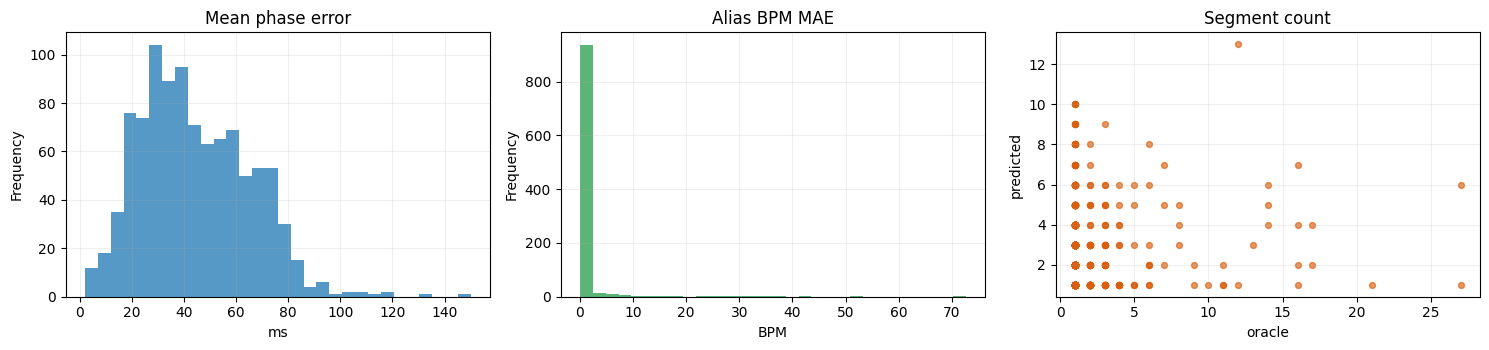

,worst_score,mean_phase_error_ms,local_bpm_alias_mae,abs_segment_count_delta,artist,title,version,oracle_bpms,predicted_bpms,selection_key
971,18.338575,26.996951,72.615693,7.0,LUZE,"Love Song ""Negradolna""",Normal,[555.5],"[139.333, 139.333, 142.875, 52.5, 150.125, 139.333, 75.0, 150.111]",4k_2to6_unique_le3:2127480:4868074:0/2127480/audio.mp3
87,14.641351,58.871210,51.509706,6.0,7_7,Shine,Extra,[255.0],"[127.375, 143.0, 38.5, 32.0, 79.0, 32.0, 95.667]",4k_2to6_unique_le3:2123187:4461952:0/2123187/audio.mp3
148,14.225839,64.118173,41.921005,9.0,Silentroom vs. Frums,Aegleseeker,Abraxos vs. guden's Future,[234.0],"[73.0, 157.778, 147.667, 48.5, 37.5, 161.875, 176.333, 116.875, 58.0, 146.667]",4k_2to6_unique_le3:1777235:3639605:0/1777235/audio.mp3
326,12.205718,52.580199,38.011915,8.0,goreshit,slavik goblins,Quick Draw's 4K MX,[270.0],"[133.667, 136.333, 269.556, 169.556, 136.0, 269.778, 169.556, 169.556, 34.0]",4k_2to6_unique_le3:322331:726562:0/322331/slavik goblins_209242966_soundcloud.mp3
672,11.519680,56.028484,7.796682,21.0,Toromaru,Deorbit,Advanced,[170.0],"[170.111, 113.875, 52.5, 169.875, 91.0, 88.222]",4k_2to6_unique_le3:2048064:4284892:0/2048064/audio.mp3
317,11.470634,66.789003,34.050219,6.0,II-L,Unidentified Frequency Op.3 (Type-Triangle),Hard,[170.0],"[244.778, 122.333, 243.222, 244.75, 170.0, 244.778, 244.778]",4k_2to6_unique_le3:1632950:3333163:0/1632950/audio.mp3
683,11.229058,118.907239,8.527704,10.0,Chroma,[@__@],[OwO],[158.0],"[158.0, 99.778, 158.0, 157.875]",4k_2to6_unique_le3:1726083:3527480:0/1726083/audio.mp3
454,11.204082,105.299003,16.679279,8.0,Kikuo,Gangu Kyou Sou Kyoku -Shuuen-,4K MASTER,[130.0],"[86.667, 260.667, 260.778, 130.333, 173.778, 260.778, 173.333, 260.778, 260.778]",4k_2to6_unique_le3:1080799:2261097:0/1080799/audio.mp3
185,10.970919,29.999053,0.000000,26.0,Toromaru,Uncharted Sky,4K Extra,[164.0],[164.0],4k_2to6_unique_le3:2219350:4733737:0/2219350/audio.mp3
992,10.766766,118.748379,22.328707,2.0,II-L feat. amelie xoxo,THE EARTH,Solstice | Another,[128.0],"[89.556, 179.111, 25.5, 102.5, 125.111, 128.333, 103.333, 41.5]",4k_2to6_unique_le3:2002137:4163449:0/2002137/audio.mp3


### LUZE - Love Song "Negradolna" [Normal]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,18.338575,26.996951,72.615693,1,8.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,480.0,108.010801,555.5,4


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,570.622011,430.622011,139.333333,4
1,23473.588572,430.622011,139.333333,4
2,45394.330709,419.947507,142.875000,4
3,64560.000000,1142.857143,52.500000,4
4,77275.720233,399.666944,150.125000,4
5,92373.110268,430.622011,139.333333,4
6,102300.000000,800.000000,75.000000,4
7,114735.025992,399.703923,150.111111,4


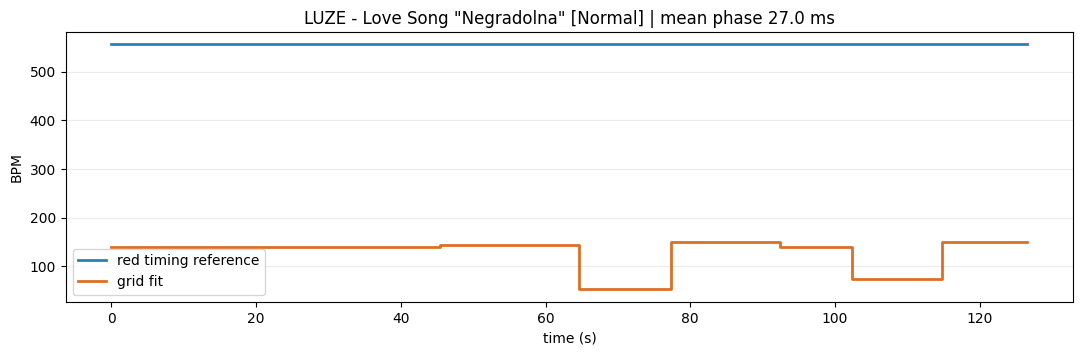

### 7_7 - Shine [Extra]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,14.641351,58.87121,51.509706,1,7.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,18.0,235.294118,255.0,4


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,1002.100098,471.050049,127.375000,4
1,21918.181818,419.580420,143.000000,4
2,30570.389610,1558.441558,38.500000,4
3,48075.000000,1875.000000,32.000000,4
4,59560.506329,759.493671,79.000000,4
5,93275.000000,1875.000000,32.000000,4
6,106433.030990,627.177698,95.666667,4


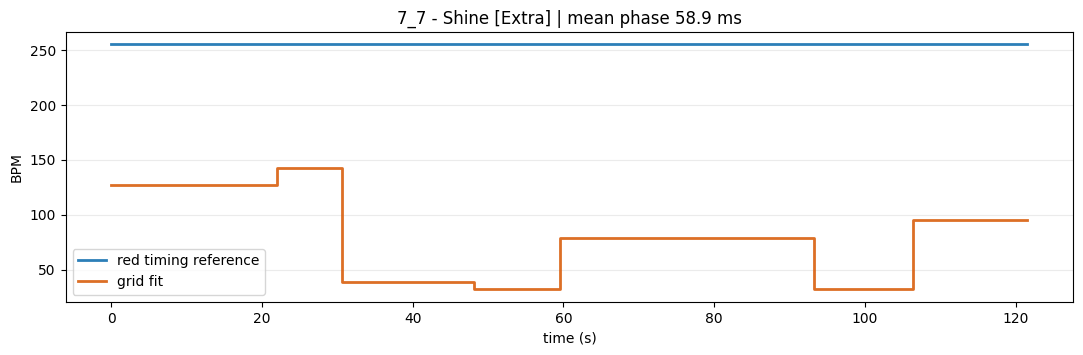

### Silentroom vs. Frums - Aegleseeker [Abraxos vs. guden's Future]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,14.225839,64.118173,41.921005,1,10.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,1007.0,256.410256,234.0,4


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,1041.917808,821.917808,73.000000,4
1,17112.394343,380.281690,157.777778,4
2,29495.078941,406.320541,147.666667,4
3,49027.422680,1237.113402,48.500000,4
4,56140.000000,1600.000000,37.500000,4
5,69492.741313,370.656371,161.875000,4
6,82444.045524,340.264651,176.333333,4
7,91286.310160,513.368984,116.875000,4
8,118911.034483,1034.482759,58.000000,4
9,132356.363336,409.090908,146.666667,4


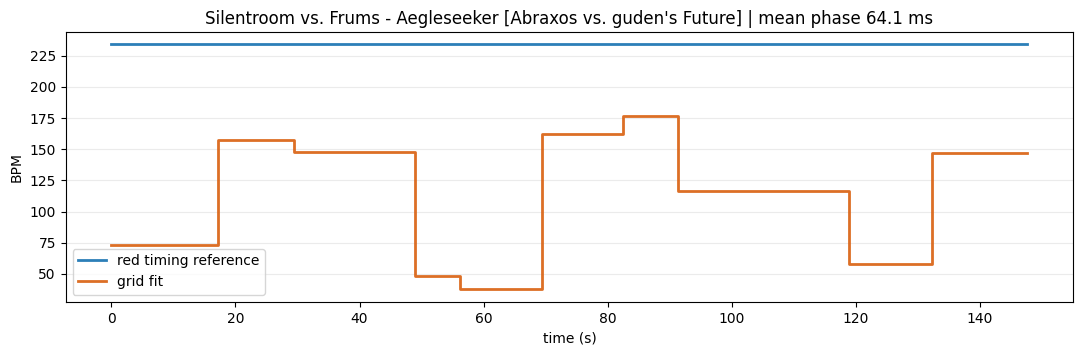

### goreshit - slavik goblins [Quick Draw's 4K MX]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,12.205718,52.580199,38.011915,1,9.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,0.0,222.222222,270.0,4


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,1746.633413,448.877804,133.666667,4
1,10742.347214,440.097801,136.333333,4
2,23126.628157,222.588623,269.555556,4
3,63682.070607,353.866316,169.555556,4
4,88996.470588,441.176471,136.000000,4
5,110250.609465,222.405272,269.777778,4
6,119512.948573,353.866316,169.555556,4
7,139055.595967,353.866316,169.555556,4
8,148855.294118,1764.705882,34.000000,4


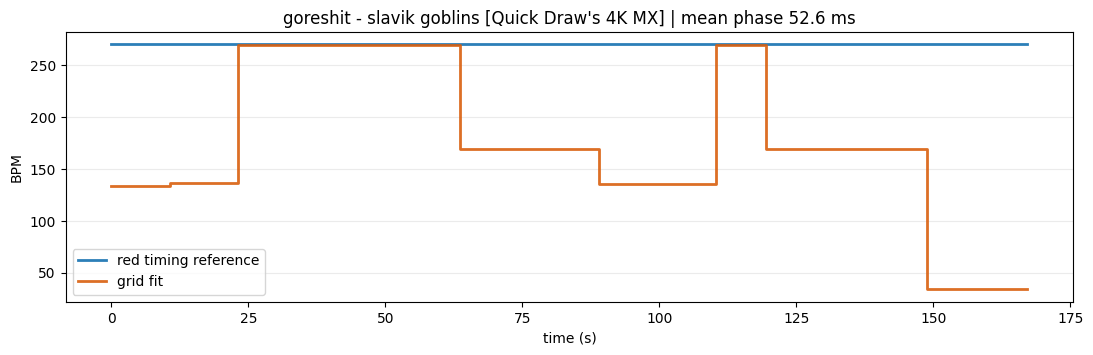

### Toromaru - Deorbit [Advanced]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,11.51968,56.028484,7.796682,27,6.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,1400.0,352.941176,170.0,4
1,2811.0,352.941176,170.0,5
2,13399.0,352.941176,170.0,4
3,30341.0,352.941176,170.0,7
4,37752.0,352.941176,170.0,3
5,45164.0,352.941176,170.0,5
6,46929.0,352.941176,170.0,4
7,49752.0,352.941176,170.0,7
8,52047.0,352.941176,170.0,7
9,54341.0,352.941176,170.0,7


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,725.421294,352.710647,170.111111,4
1,36228.759605,526.893524,113.875000,4
2,48660.000000,1142.857143,52.500000,4
3,57891.743929,353.200883,169.875000,4
4,109291.208791,659.340659,91.000000,4
5,119357.632542,680.100757,88.222222,4


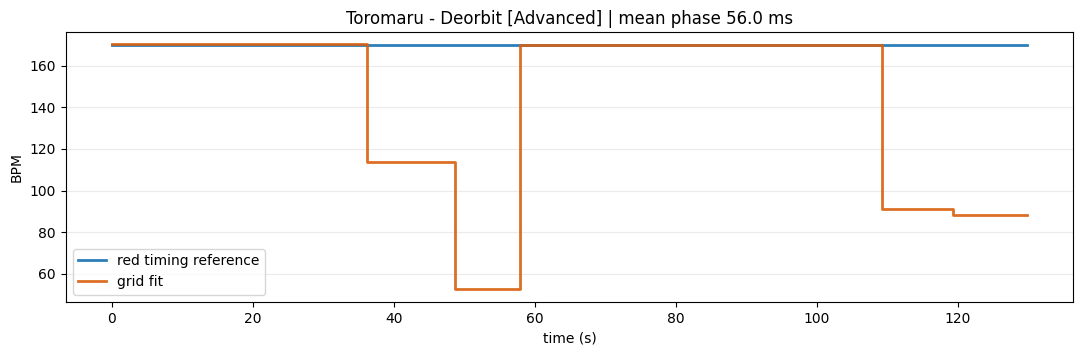

### II-L - Unidentified Frequency Op.3 (Type-Triangle) [Hard]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,11.470634,66.789003,34.050219,1,7.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,1419.0,352.941176,170.0,4


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,245.120290,245.120290,244.777778,4
1,13752.970065,490.463217,122.333333,4
2,29929.246258,246.687986,243.222222,4
3,38057.957099,245.148110,244.750000,4
4,66020.000000,352.941176,170.000000,4
5,115651.656727,245.120290,244.777778,4
6,138492.964014,245.120290,244.777778,4


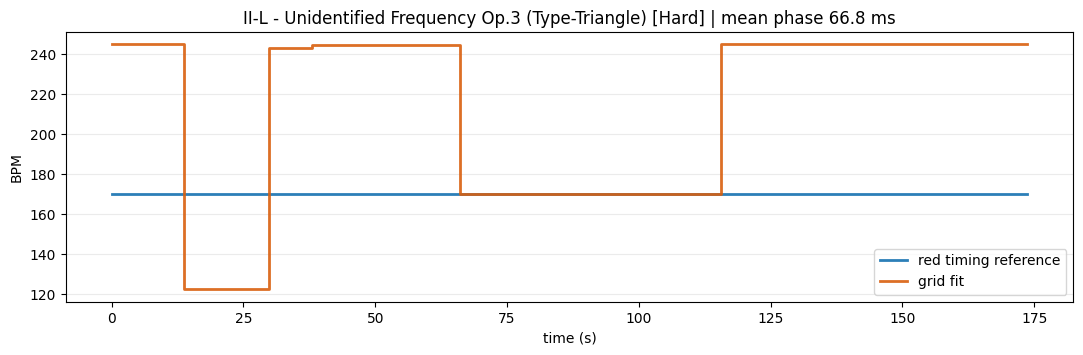

### Chroma - [@__@] [[OwO]]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,11.229058,118.907239,8.527704,14,4.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,993.0,379.746835,158.0,4
1,13144.0,379.746835,158.0,6
2,19219.0,379.746835,158.0,6
3,23775.0,379.746835,158.0,4
4,26812.0,379.746835,158.0,4
5,38963.0,379.746835,158.0,6
6,45038.0,379.746835,158.0,6
7,50924.0,379.746835,158.0,4
8,55480.0,379.746835,158.0,4
9,55668.0,379.746835,158.0,4


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,839.493671,379.746835,158.000000,4
1,32992.160284,601.336302,99.777778,4
2,54563.797468,379.746835,158.000000,4
3,75629.406176,380.047506,157.875000,4


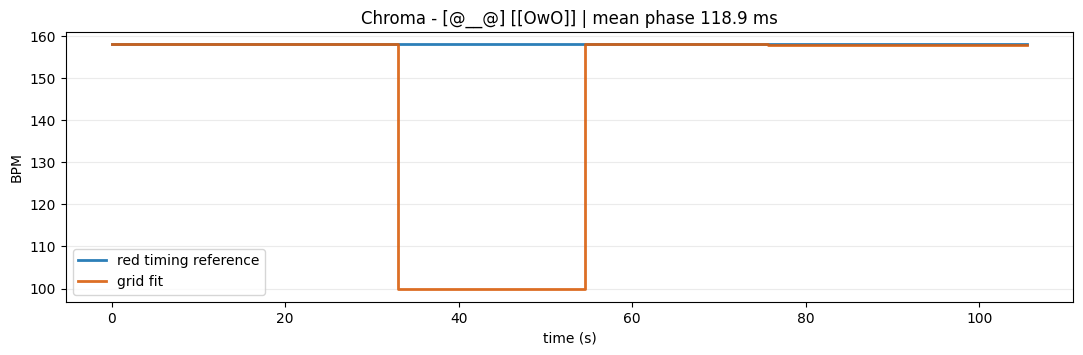

### Kikuo - Gangu Kyou Sou Kyoku -Shuuen- [4K MASTER]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,11.204082,105.299003,16.679279,1,9.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,926.0,461.538462,130.0,3


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,2316.923069,692.307690,86.666667,4
1,30043.273734,230.179029,260.666666,4
2,47366.595614,230.080954,260.777778,4
3,67412.276387,460.358057,130.333333,4
4,82313.912938,345.268542,173.777778,4
5,97884.405541,230.080954,260.777778,4
6,106875.384205,346.153845,173.333334,4
7,119592.015237,230.080954,260.777778,4
8,135977.843940,230.080954,260.777778,4


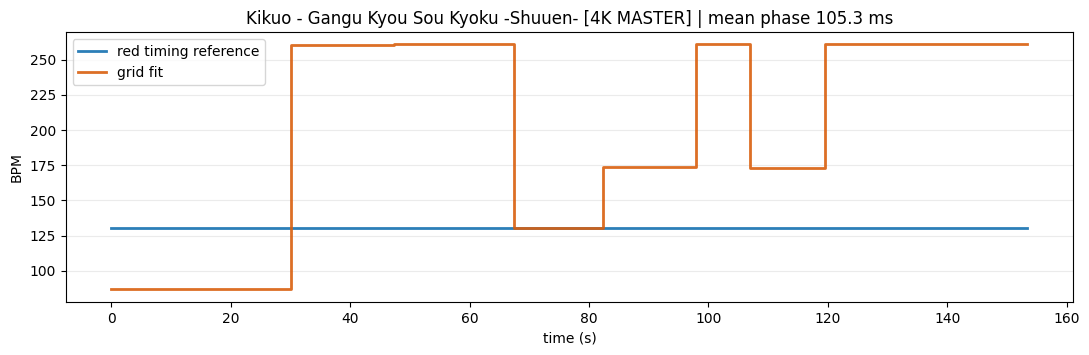

### Toromaru - Uncharted Sky [4K Extra]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,10.970919,29.999053,0.0,27,1.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,356.0,365.853659,164.0,3
1,1454.0,365.853659,164.0,4
2,10234.0,365.853659,164.0,3
3,12429.0,365.853659,164.0,4
4,13709.0,365.853659,164.0,4
5,14989.0,365.853659,164.0,4
6,16269.0,365.853659,164.0,5
7,17915.0,365.853659,164.0,4
8,42793.0,365.853659,164.0,5
9,44622.0,365.853659,164.0,4


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,1097.560976,365.853659,164.0,4


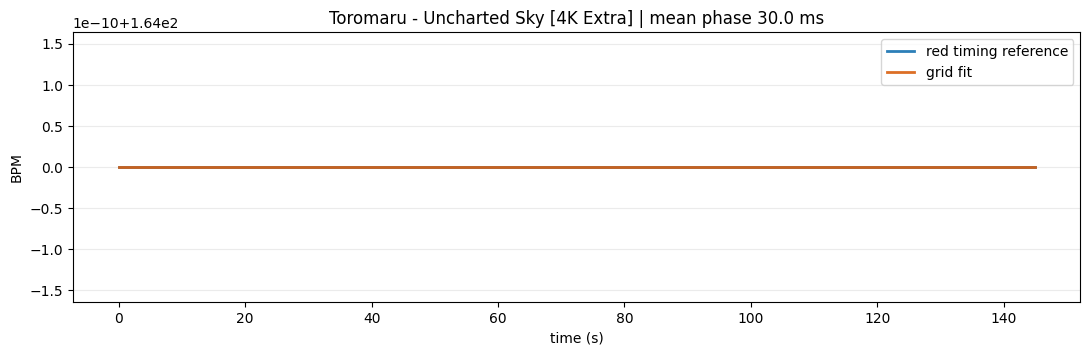

### II-L feat. amelie xoxo - THE EARTH [Solstice | Another]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,10.766766,118.748379,22.328707,6,8.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,581.0,468.75,128.0,5
1,113198.0,468.75,128.0,5
2,115776.0,468.75,128.0,5
3,117768.0,468.75,128.0,5
4,119525.0,468.75,128.0,5
5,121282.0,468.75,128.0,5


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,580.000000,669.975183,89.555556,4
1,18999.305223,334.987593,179.111111,4
2,33401.176471,2352.941176,25.500000,4
3,45193.170732,585.365854,102.500000,4
4,70877.335764,479.573713,125.111111,4
5,79500.519687,467.532469,128.333333,4
6,94444.516432,580.645163,103.333333,4
7,119874.216867,1445.783133,41.500000,4


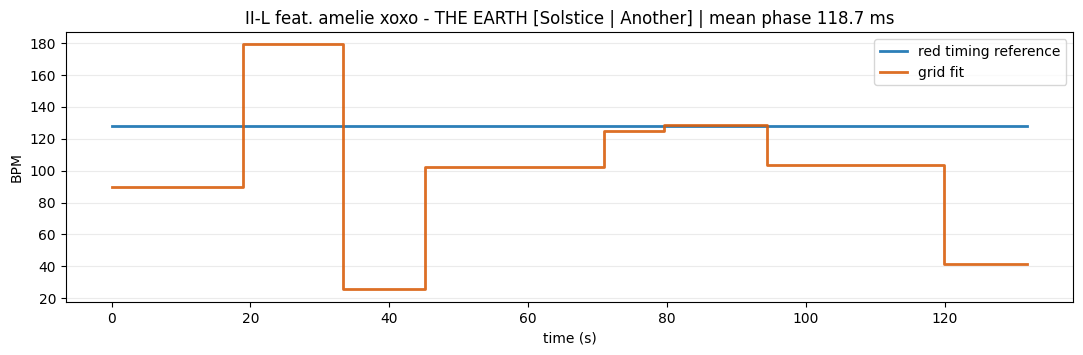

### Frums - Orthoplexed [Insane]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,10.401804,70.825,27.734171,3,9.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,-18.0,300.0,200.0,4
1,3242.0,300.0,200.0,4
2,3542.0,300.0,200.0,4


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,1179.334074,599.334074,100.111111,4
1,29993.481219,598.669624,100.222222,4
2,42876.179924,299.833426,200.111111,4
3,55488.721805,451.127820,133.000000,4
4,65890.162991,460.210930,130.375000,4
5,75036.907594,439.158280,136.625000,4
6,83980.000000,1200.000000,50.000000,4
7,104386.289171,449.251246,133.555556,4
8,117133.932584,449.438202,133.500000,4


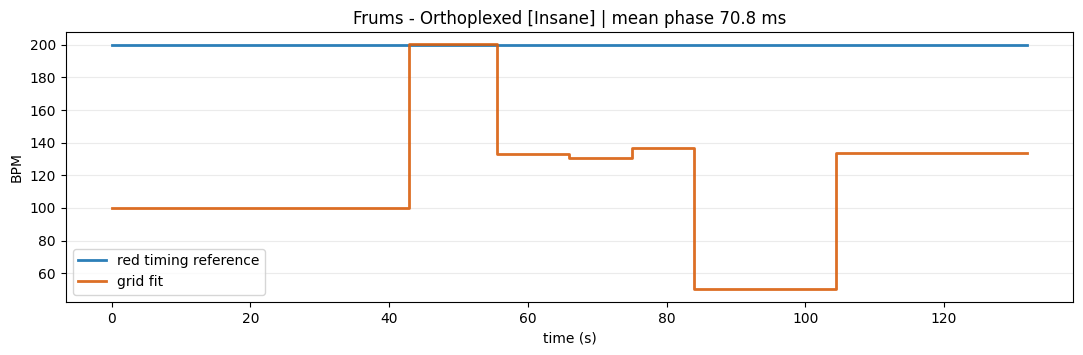

### Diceros Bicornis - Calamity Tempest [NOVICE]

,metric,value,mean_phase_error_ms,local_bpm_alias_mae,oracle_segments,predicted_segments
0,worst_score,10.237937,63.57887,25.25982,14,6.0


Oracle BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,1234.0,309.278351,194.0,5
1,3708.0,309.278351,194.0,7
2,16697.0,309.278351,194.0,4
3,20099.0,309.278351,194.0,4
4,23501.0,309.278351,194.0,3
5,25356.0,309.278351,194.0,4
6,27984.0,309.278351,194.0,4
7,37880.0,309.278351,194.0,7
8,46849.0,309.278351,194.0,4
9,51797.0,309.278351,194.0,3


Predicted BPM segments

,offset_ms,beat_length_ms,bpm,meter
0,880.640569,240.213523,249.777778,4
1,16233.621691,309.877340,193.625000,4
2,47993.753269,226.700252,264.666666,4
3,59573.501212,308.924485,194.222222,4
4,93293.170505,439.024389,136.666667,4
5,104953.664678,419.254659,143.111111,4


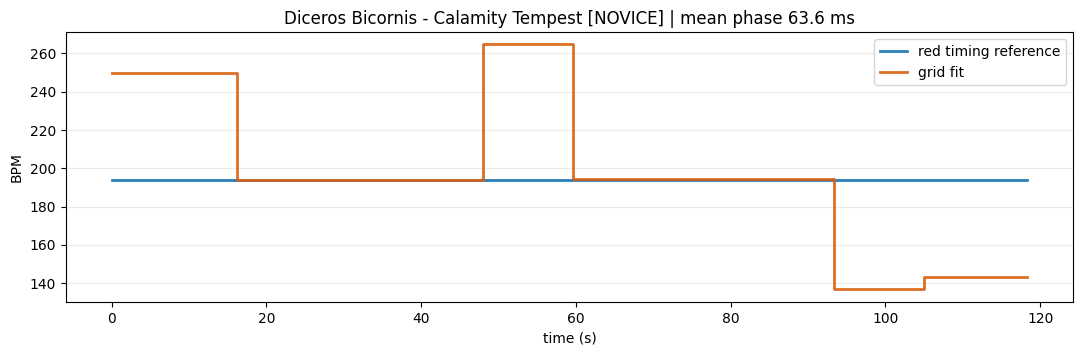

In [20]:
plot_metric_overview(summary_df)

worst_df = rank_worst(summary_df, metric=WORST_METRIC, n=WORST_N) if not summary_df.empty else pd.DataFrame()
worst_columns = [
    "worst_score",
    "mean_phase_error_ms",
    "local_bpm_alias_mae",
    "abs_segment_count_delta",
    "artist",
    "title",
    "version",
    "oracle_bpms",
    "predicted_bpms",
    "selection_key",
]
display(worst_df[[column for column in worst_columns if column in worst_df.columns]] if not worst_df.empty else worst_df)

if results and not summary_df.empty:
    display_worst_cases(results, summary_df, metric=WORST_METRIC, n=min(PLOT_WORST_N, WORST_N))


In [ ]:
display(Markdown("## Refined worst cases"))
plot_metric_overview(refined_summary_df)

refined_worst_columns = [
    "worst_score",
    "mean_phase_error_ms",
    "local_bpm_alias_mae",
    "abs_segment_count_delta",
    "artist",
    "title",
    "version",
    "oracle_bpms",
    "predicted_bpms",
    "selection_key",
]
display(
    refined_worst_df[[column for column in refined_worst_columns if column in refined_worst_df.columns]]
    if not refined_worst_df.empty
    else refined_worst_df
)

if refined_results and not refined_summary_df.empty:
    display_worst_cases(
        refined_results,
        refined_summary_df,
        metric=WORST_METRIC,
        n=min(REFINED_PLOT_WORST_N, REFINED_WORST_N),
    )
